In [21]:
import yfinance as yf
import pandas as pd

reliance = yf.download(
    "RELIANCE.NS",
    start="2020-01-01",
    end="2025-01-01",
    auto_adjust=True
)

reliance.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2020-01-01,672.216125,680.008790,670.390471,675.956609,14004468
2020-01-02,683.660278,686.176208,673.284921,673.284921,17710316
2020-01-03,684.484009,686.487835,678.183067,682.636001,20984698
2020-01-06,668.609314,680.365044,667.050769,676.847260,24519177
2020-01-07,678.895569,683.303975,673.952766,676.401873,16683622


In [22]:
import numpy as np

# Daily Returns
reliance["Returns"] = reliance["Close"].pct_change()

# RSI already created on Day 3
# If not present, recreate it
delta = reliance["Close"].diff()

gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)

avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()

rs = avg_gain / avg_loss

reliance["RSI"] = 100 - (100 / (1 + rs))

In [23]:
reliance[["Close","Returns","Volume","RSI"]].head()

Price,Close,Returns,Volume,RSI
Ticker,RELIANCE.NS,,RELIANCE.NS,
Date,,,,
2020-01-01,672.216125,NaN,14004468,NaN
2020-01-02,683.660278,0.017025,17710316,NaN
2020-01-03,684.484009,0.001205,20984698,NaN
2020-01-06,668.609314,-0.023192,24519177,NaN
2020-01-07,678.895569,0.015385,16683622,NaN


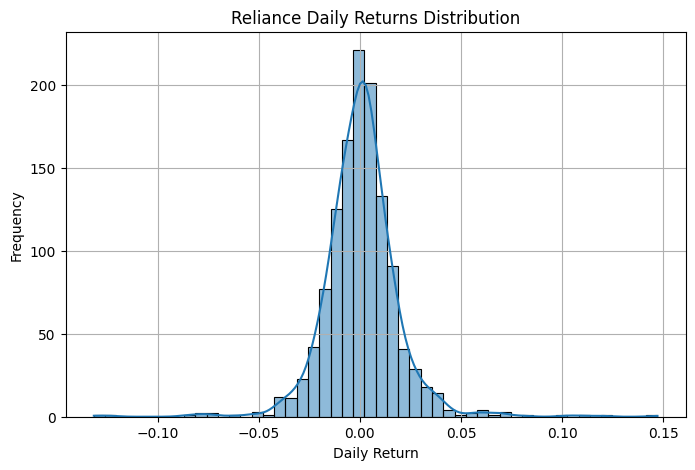

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.histplot(
    reliance["Returns"].dropna(),
    bins=50,
    kde=True
)

plt.title("Reliance Daily Returns Distribution")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.grid(True)

plt.savefig(
    "../images/returns_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

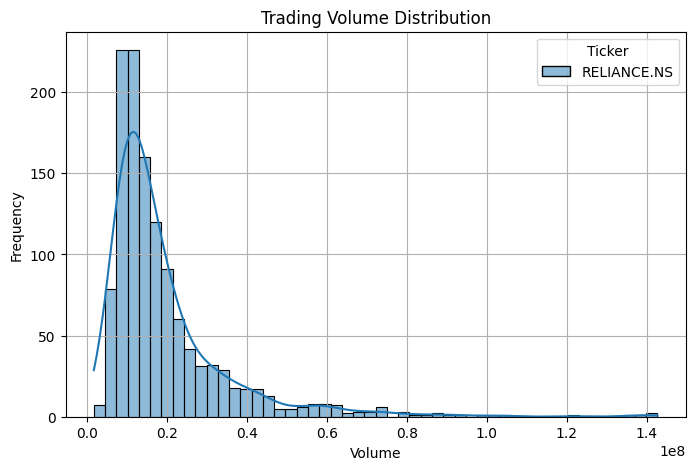

In [25]:
plt.figure(figsize=(8,5))

sns.histplot(
    reliance["Volume"],
    bins=50,
    kde=True
)

plt.title("Trading Volume Distribution")
plt.xlabel("Volume")
plt.ylabel("Frequency")

plt.grid(True)

plt.savefig(
    "../images/volume_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

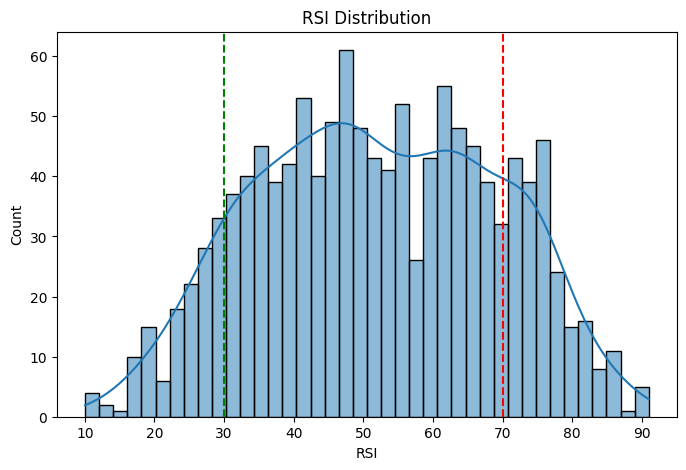

In [26]:
plt.figure(figsize=(8,5))

sns.histplot(
    reliance["RSI"].dropna(),
    bins=40,
    kde=True
)

plt.axvline(70, color="red", linestyle="--")
plt.axvline(30, color="green", linestyle="--")

plt.title("RSI Distribution")

plt.savefig(
    "../images/rsi_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

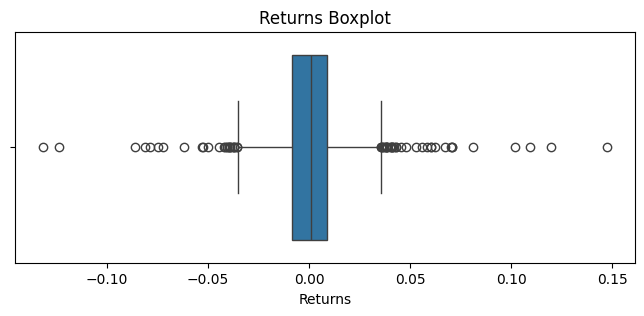

In [27]:
plt.figure(figsize=(8,3))

sns.boxplot(
    x=reliance["Returns"].dropna()
)

plt.title("Returns Boxplot")

plt.savefig(
    "../images/returns_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [28]:
print(type(reliance["Volume"]))
print(reliance["Volume"].head())

<class 'pandas.core.frame.DataFrame'>
Ticker      RELIANCE.NS
Date                   
2020-01-01     14004468
2020-01-02     17710316
2020-01-03     20984698
2020-01-06     24519177
2020-01-07     16683622


In [29]:
print(reliance.columns)
print(type(reliance["Volume"]))

MultiIndex([(  'Close', 'RELIANCE.NS'),
            (   'High', 'RELIANCE.NS'),
            (    'Low', 'RELIANCE.NS'),
            (   'Open', 'RELIANCE.NS'),
            ( 'Volume', 'RELIANCE.NS'),
            ('Returns',            ''),
            (    'RSI',            '')],
           names=['Price', 'Ticker'])
<class 'pandas.core.frame.DataFrame'>


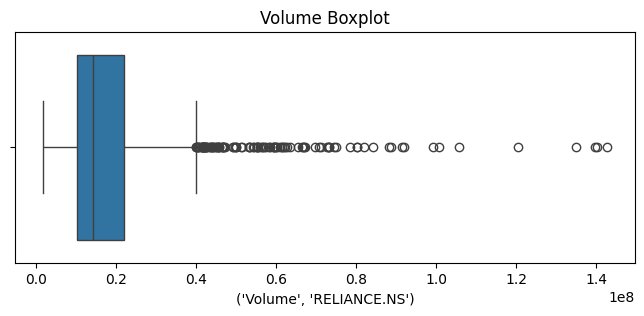

In [30]:
# plt.figure(figsize=(8,3))

# sns.boxplot(
#     x=reliance["Volume"]
# )

# plt.title("Volume Boxplot")

# plt.savefig(
#     "../images/volume_boxplot.png",
#     dpi=300,
#     bbox_inches="tight"
# )

# plt.show()

volume = reliance[("Volume", "RELIANCE.NS")]

plt.figure(figsize=(8,3))

sns.boxplot(x=volume)

plt.title("Volume Boxplot")

plt.savefig(
    "../images/volume_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [31]:
reliance["Regime"] = "Neutral"

reliance.loc[
    reliance["RSI"] > 70,
    "Regime"
] = "Overbought"

reliance.loc[
    reliance["RSI"] < 30,
    "Regime"
] = "Oversold"

In [32]:
reliance["Regime"].value_counts()

Regime
Neutral       878
Overbought    226
Oversold      134
Name: count, dtype: int64

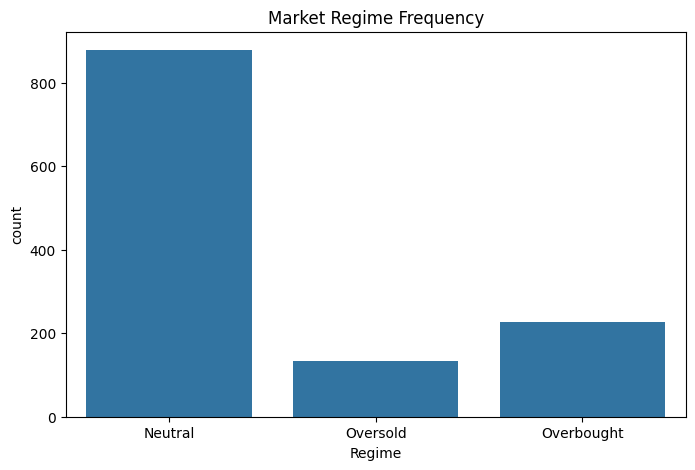

In [33]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Regime",
    data=reliance
)

plt.title("Market Regime Frequency")

plt.savefig(
    "../images/regime_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()